Isaac Noe

8/4/2026

Code lab 6 — Spinning & Rolling Objects

In [31]:
import numpy as np
import matplotlib.pyplot as plt

Part A — The Physical Pendulum (25 points)

In [32]:
# Part 1
# Simulating a uniform rod

m, g, L = 1.0, 9.81, 1.0
d = L / 2
I = (1 / 3) * m * L**2

def rotate_step(theta, omega, torque, I, dt):
    """Euler-Cromer step for rotation."""
    alpha = torque / I
    omega += alpha * dt
    theta += omega * dt
    return theta, omega

def torque(theta):
    return -m * g * d * np.sin(theta)

dt = 0.001
steps = 10_000

times = np.arange(steps + 1) * dt
angles = np.empty(steps + 1)

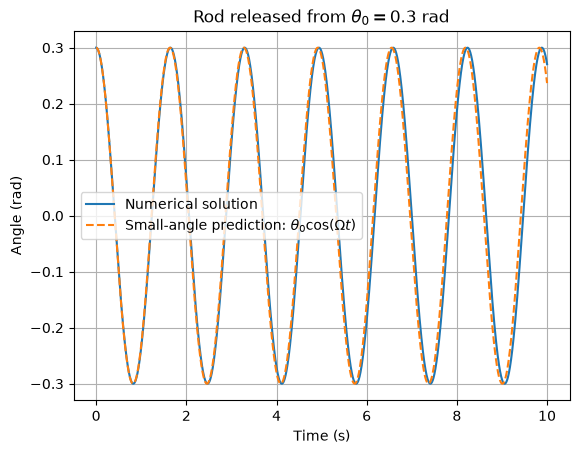

In [33]:
# Part 2
# Releasing from 0.3 rad

theta0 = 0.3
omega = 0.0
theta = theta0
angles[0] = theta

for i in range(steps):
    theta, omega = rotate_step(theta, omega, torque(theta), I, dt)
    angles[i + 1] = theta

Omega = np.sqrt(m * g * d / I)
small_angle = theta0 * np.cos(Omega * times)

plt.plot(times, angles, label="Numerical solution")
plt.plot(times, small_angle, "--", label=r"Small-angle prediction: $\theta_0\cos(\Omega t)$")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title(r"Rod released from $\theta_0 = 0.3$ rad")
plt.grid()
plt.legend()
plt.show()

This graph shows the calculated angle of a rod released at 0.3 rad as a function of time compared to the predicted angle using small angle approximation.

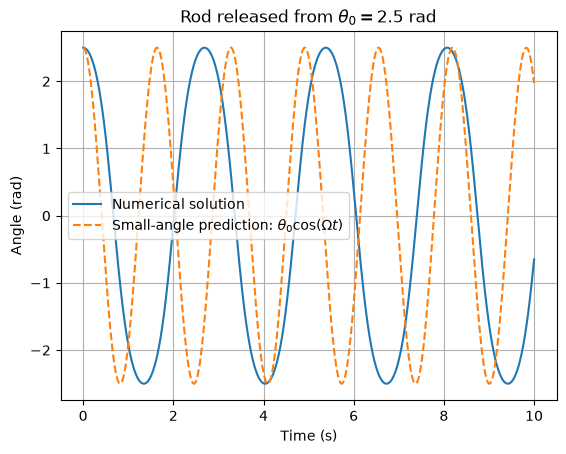

In [34]:
# Part 3
# Releasing from 2.5 rad

theta0 = 2.5
theta = theta0
omega = 0.0
angles[0] = theta

for i in range(steps):
    theta, omega = rotate_step(theta, omega, torque(theta), I, dt)
    angles[i + 1] = theta

small_angle = theta0 * np.cos(Omega * times)

plt.plot(times, angles, label="Numerical solution")
plt.plot(times, small_angle, "--", label=r"Small-angle prediction: $\theta_0\cos(\Omega t)$")
plt.xlabel("Time (s)")
plt.ylabel("Angle (rad)")
plt.title(r"Rod released from $\theta_0 = 2.5$ rad")
plt.grid()
plt.legend()
plt.show()

This graph shows the calculated angle of a rod released at 2.5 rad as a function of time compared to the predicted angle using small angle approximation.

Part 4

At large amplitude, is the real period longer or shorter than the small-angle prediction?  Explain the connection to the nonlinear pendulum you saw in Lab 3.

The period is longer than the small-angle prediction. The pendulum has the same amplitude dependence as the rod.

Part B — The Rolling Race (35 points)

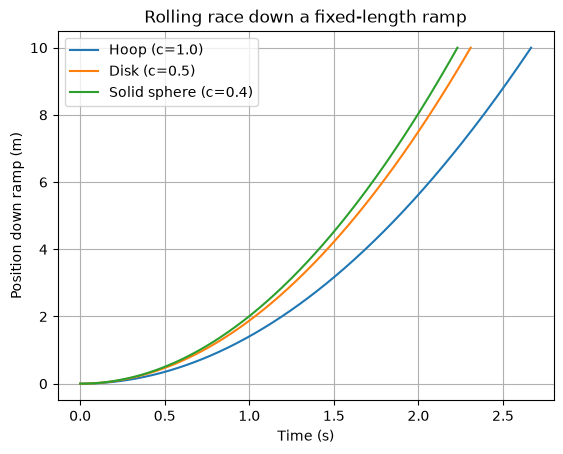

Finishing order and times:
1. Solid sphere: 2.231 s
2. Disk: 2.309 s
3. Hoop: 2.666 s


In [36]:
# Parts 1–2
# Simulating and plotting the race

def rolling_accel(theta_incline, c, g=9.81):
    """Linear acceleration down an incline for a rolling body.
    c = I/(m R^2): hoop=1, disk=0.5, sphere=0.4."""
    return g * np.sin(theta_incline) / (1 + c)

length = 10.0
angle = np.deg2rad(35.0)
mass = 1.0
radius = 0.10
bodies = {"Hoop": 1.0, "Disk": 0.5, "Solid sphere": 0.4}
race_results = {}

for body_name, c_value in bodies.items():
    acceleration = rolling_accel(angle, c_value, g=g)
    finish_time = np.sqrt(2 * length / acceleration)
    race_time = np.linspace(0, finish_time, 500)
    positions = 0.5 * acceleration * race_time**2
    race_results[body_name] = (finish_time, acceleration)
    plt.plot(race_time, positions, label=f"{body_name} (c={c_value})")

plt.xlabel("Time (s)")
plt.ylabel("Position down ramp (m)")
plt.title("Rolling race down a fixed-length ramp")
plt.grid()
plt.legend()
plt.show()

print("Finishing order and times:")
for place, (body_name, (finish_time, _)) in enumerate(
    sorted(race_results.items(), key=lambda item: item[1][0]), start=1):
    print(f"{place}. {body_name}: {finish_time:.3f} s")

This graph shows a hoop, disk, and a sphere rolling down a ramp.

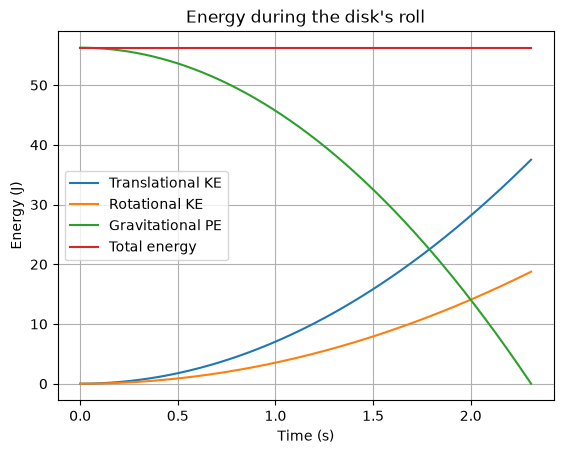

Rotational fraction of final kinetic energy: 33.3%


In [37]:
# Part 3
# Energy partition for the disk
energy_body = "Disk"
energy_c = bodies[energy_body]
energy_acceleration = rolling_accel(angle, energy_c, g=g)
energy_finish_time = race_results[energy_body][0]
energy_times = np.linspace(0, energy_finish_time, 500)

energy_positions = 0.5 * energy_acceleration * energy_times**2
energy_velocities = energy_acceleration * energy_times
energy_inertia = energy_c * mass * radius**2

translational_ke = 0.5 * mass * energy_velocities**2
rotational_ke = 0.5 * energy_inertia * (energy_velocities / radius)**2
gravitational_pe = mass * g * (length - energy_positions) * np.sin(angle)
total_energy = translational_ke + rotational_ke + gravitational_pe

plt.plot(energy_times, translational_ke, label="Translational KE")
plt.plot(energy_times, rotational_ke, label="Rotational KE")
plt.plot(energy_times, gravitational_pe, label="Gravitational PE")
plt.plot(energy_times, total_energy, label="Total energy")
plt.xlabel("Time (s)")
plt.ylabel("Energy (J)")
plt.title(f"Energy during the {energy_body.lower()}'s roll")
plt.grid()
plt.legend()
plt.show()


rotation_fraction = rotational_ke[-1] / (translational_ke[-1] + rotational_ke[-1])
print(f"Rotational fraction of final kinetic energy: {rotation_fraction:.1%}")

This graph shows the translational KE, rotational KE, gravitational PE, and total energy over the roll as a function of time.

Part 4

Analysis:  Explain why the order is sphere → disk → hoop regardless of mass or radius.  Why does the mass cancel out entirely?

The finish in that order because of how their mass is distributed. The gravity and the inertia scale with mass so it drops out of the acceleration.

Part C — Angular Momentum Conservation (40 points)

In [38]:
# Part 1
# Define a torque-free spinning-body model

def simulate_spinning_body(I0, omega0, total_time, dt, change_start, change_duration,
                    reduction_factor=0.5):

    time = np.arange(0, total_time + dt / 2, dt)
    I_final = I0 * reduction_factor

    # Hold I constant, reduce it linearly during the interval, then hold it again.
    I_values = np.interp(
        time,
        [0, change_start, change_start + change_duration, total_time],
        [I0, I0, I_final, I_final],
    )

    L0 = I0 * omega0
    omega_values = L0 / I_values
    L_values = I_values * omega_values
    rotational_ke = 0.5 * I_values * omega_values**2

    return time, I_values, omega_values, L_values, rotational_ke

In [39]:
# Part 2
# Call the function with a halfed I
time, I, omega, L, ke = simulate_spinning_body(
    2.0, 3.0, 10.0, 0.01, 5.0, 1.0, 0.5)

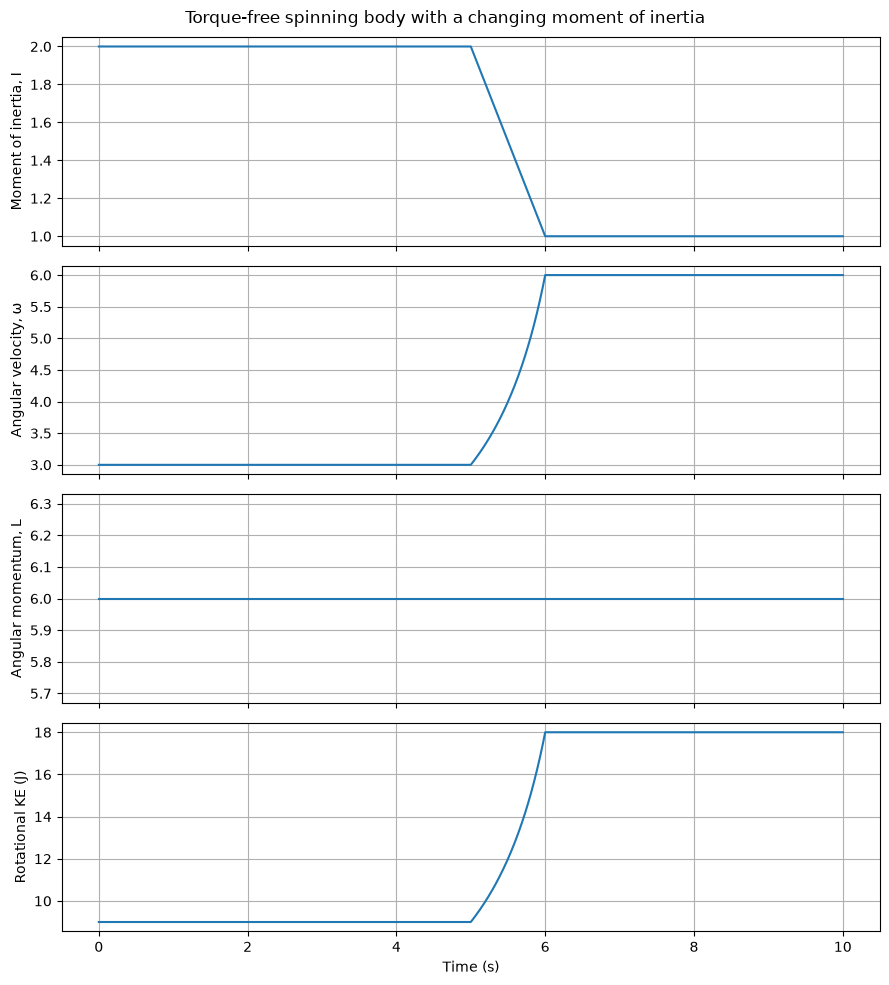

In [40]:
# Part 3
# Plot it
fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(time, I)
axes[0].set_ylabel("Moment of inertia, I")
axes[0].grid()

axes[1].plot(time, omega)
axes[1].set_ylabel("Angular velocity, ω")
axes[1].grid()

axes[2].plot(time, L)
axes[2].set_ylabel("Angular momentum, L")
axes[2].grid()

axes[3].plot(time, ke)
axes[3].set_ylabel("Rotational KE (J)")
axes[3].set_xlabel("Time (s)")
axes[3].grid()

fig.suptitle("Torque-free spinning body with a changing moment of inertia")
fig.tight_layout()
plt.show()

These graphs show I(t), ω(t), L(t), and rotational KE(t) of a rotating body with a changing inertia as a function of time .

Part 4

Confirm and explain:  L stays constant, ω rises when I drops, but KE increases.  Where does the extra kinetic energy come from?  Why doesn't this violate energy conservation?

The extra kinetic energy comes from the change in the inertia (Like a skater pulling their arms in while spinning).

Part 5

Bring it together: list the three conservation laws you've now used as diagnostics across the course (energy, linear momentum, angular momentum) and give one example of a bug each one would catch.

Energy conservation would catch a bug that adds energy to a closed system.
Linear momentum conservation would catch a bug that increases acceleration for no reason.
Angular momentum conservation would catch a bug that changed the inertia for no reason.